# Deutsch-Jozsa Algorithm: Constant Oracle

## 1. Objective
The objective of this experiment is to implement, simulate, and analyze the **Deutsch-Jozsa Algorithm** for an $n = 3$ input-qubit register evaluating a constant Boolean function:
$$f: \{0, 1\}^3 \to \{0, 1\}, \quad f(x) = 0 \quad \forall x \in \{0, 1\}^3$$

The experiment demonstrates that quantum superposition, phase kickback, and constructive interference allow an observer to classify the Boolean function as **constant** using only a **single oracle query**, achieving an exponential query complexity advantage over classical deterministic algorithms.

---

## 2. Theoretical Background

### The Deutsch-Jozsa Problem
Given a black-box oracle implementing a Boolean function $f: \{0, 1\}^n \to \{0, 1\}$, with the promise that $f$ is either:
- **Constant**: $f(x)$ yields the same binary value ($0$ or $1$) for all $2^n$ inputs.
- **Balanced**: $f(x)$ yields $0$ for exactly half ($2^{n-1}$) of the inputs and $1$ for the remaining half ($2^{n-1}$).

### Classical vs. Quantum Query Complexity
- **Classical Worst-Case**: To certify with $100\%$ certainty whether $f$ is constant or balanced, a classical deterministic algorithm must query at least:
  $$Q_{\text{classical}} = 2^{n-1} + 1$$
  For $n = 3$, $2^{3-1} + 1 = 5$ function evaluations are required.
- **Quantum Advantage**: The Deutsch-Jozsa algorithm determines the global nature of $f$ with certainty using exactly **$1$ quantum query** ($O(1)$), demonstrating an exponential query speedup.

### Role of the Ancilla Qubit and Phase Kickback
The system uses $n$ query qubits and $1$ auxiliary (ancilla) qubit:
- The ancilla qubit ($q_n = q_3$) is initialized to $|1\rangle$ via a Pauli-$X$ gate and transformed into the orthogonal state $|-\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}$ via a Hadamard gate.
- The oracle unitary operator $U_f$ maps $|x\rangle |y\rangle \to |x\rangle |y \oplus f(x)\rangle$.
- When applied to the state $|x\rangle |-\rangle$, the action produces **phase kickback**:
  $$U_f |x\rangle |-\rangle = (-1)^{f(x)} |x\rangle |-\rangle$$
  The function value $f(x)$ is kick-backed directly as a relative phase $(-1)^{f(x)}$ on the input state $|x\rangle$, leaving the ancilla unchanged.

### Quantum Interference and Function Classification
1. **Parallel Superposition**:
   Applying Hadamard gates to the $n$ input qubits initialized in $|0\rangle^{\otimes n}$ produces an equal superposition:
   $$|\psi_1\rangle = \frac{1}{\sqrt{2^n}} \sum_{x \in \{0, 1\}^n} |x\rangle$$
2. **Post-Oracle State**:
   $$|\psi_2\rangle = \frac{1}{\sqrt{2^n}} \sum_{x \in \{0, 1\}^n} (-1)^{f(x)} |x\rangle$$
3. **Final Hadamard Transformation**:
   Applying $H^{\otimes n}$ to the input register transforms the state to:
   $$|\psi_3\rangle = \sum_{z \in \{0, 1\}^n} \left( \frac{1}{2^n} \sum_{x \in \{0, 1\}^n} (-1)^{f(x) + x \cdot z} \right) |z\rangle$$
   The amplitude for measuring the all-zero state $|0\rangle^{\otimes n} = |000\rangle$ ($z = 000$) is:
   $$\alpha_{000} = \frac{1}{2^n} \sum_{x \in \{0, 1\}^n} (-1)^{f(x)}$$

- **If $f$ is Constant** ($f(x) = c$):
  $$\alpha_{000} = \frac{1}{2^n} \sum_{x \in \{0, 1\}^n} (-1)^c = (-1)^c \implies P(000) = |\alpha_{000}|^2 = 1$$
  Constructive interference concentrates $100\%$ of the probability amplitude into $|000\rangle$, while all non-zero states destructively interfere to zero ($P(z \neq 000) = 0$).
- **If $f$ is Balanced**:
  $$\alpha_{000} = \frac{1}{2^n} \left( \sum_{x: f(x)=0} (+1) + \sum_{x: f(x)=1} (-1) \right) = \frac{1}{2^n} (2^{n-1} - 2^{n-1}) = 0$$
  Destructive interference ensures $P(000) = 0$, and the measurement outcome will be strictly non-zero.

---

## 3. Circuit Architecture and State Preparation

### Circuit Specifications
The circuit operates on $n + 1 = 4$ qubits:
- **Input Register ($q_0, q_1, q_2$)**: 3 qubits representing the $2^3 = 8$ computational basis inputs ($000$ to $111$).
- **Ancilla Register ($q_3$)**: 1 auxiliary qubit mediating phase kickback.

### Step-by-Step State Evolution
1. **Initialization**:
   $$|\psi_0\rangle = |0\rangle^{\otimes 3} |0\rangle_{\text{anc}} = |000\rangle |0\rangle$$
2. **Ancilla Inversion**:
   Pauli-$X$ gate applied to $q_3$:
   $$|000\rangle |0\rangle \xrightarrow{X(q_3)} |000\rangle |1\rangle$$
3. **Superposition on All Qubits**:
   Hadamard gates applied to all 4 qubits ($q_0, q_1, q_2, q_3$):
   $$|\psi_1\rangle = H^{\otimes 3}|000\rangle \otimes H|1\rangle = \left( \frac{1}{\sqrt{8}} \sum_{x \in \{0, 1\}^3} |x\rangle \right) |-\rangle$$
4. **Final Interference Transformation**:
   Hadamard gates applied to the $3$ input qubits ($q_0, q_1, q_2$):
   $$|\psi_3\rangle = (H^{\otimes 3} \otimes I) |\psi_2\rangle = |000\rangle |-\rangle$$

---

## 4. Constant Oracle Implementation ($f(x) = 0$)
The oracle evaluates the constant function $f(x) = 0$ for all $x \in \{0, 1\}^3$:
$$U_f |x\rangle |y\rangle = |x\rangle |y \oplus 0\rangle = |x\rangle |y\rangle$$

Because $y \oplus 0 = y$, the target qubit state remains identical for all input values. The unitary operator $U_f$ simplifies mathematically to the identity operation:
$$U_f = I^{\otimes 4}$$

Consequently, **no quantum gates are required** inside the oracle region. The circuit represents this directly by leaving the oracle stage empty between the two Hadamard layers.

---

## 5. Statevector Probability Analysis
To verify the analytical behavior before measurement sampling:
1. The exact 16-element complex statevector of the 4-qubit system is obtained via Qiskit's `Statevector.from_instruction(qc)`.
2. Probabilities across the $2^4 = 16$ basis states are computed via `state.probabilities()`.
3. The marginal probability of each 3-bit input state $i \in \{0, \dots, 7\}$ is calculated by tracing over the ancilla qubit ($a \in \{0, 1\}$):
   $$P(i) = \sum_{a \in \{0, 1\}} P(i + a \cdot 2^n) = P(i) + P(i + 8)$$
4. Theoretical probabilities obtained:
   $$P(000) = 1.0000, \quad P(001) = \dots = P(111) = 0.0000$$

---

## 6. Measurement Sampling Methodology
To simulate experimental execution on quantum hardware:
- **Sample Size**: $\text{SHOTS} = 1024$ measurements.
- **Reproducibility**: Parameterized using `np.random.default_rng(SEED)` with fixed seed `SEED = 42`.
- **Sampling Vector**: Drawn from the $8$-element input state probability distribution `input_probabilities`.
- **Classification Metric**:
  - `zero_count` = Number of measurements yielding state `000`.
  - `nonzero_count` = $\text{SHOTS} - \text{zero\_count}$.
  - If $\text{nonzero\_count} == 0 \implies \mathbf{CONSTANT\ FUNCTION}$.


T-01 : CONSTANT FUNCTION ORACLE

QUANTUM CIRCUIT
----------------------------------------------------------------------
     ┌───┐┌───┐
q_0: ┤ H ├┤ H ├
     ├───┤├───┤
q_1: ┤ H ├┤ H ├
     ├───┤├───┤
q_2: ┤ H ├┤ H ├
     ├───┤├───┤
q_3: ┤ X ├┤ H ├
     └───┘└───┘

MEASUREMENT RESULTS
----------------------------------------------------------------------
000 : 1024
001 : 0
010 : 0
011 : 0
100 : 0
101 : 0
110 : 0
111 : 0

PROBABILITY RESULTS
----------------------------------------------------------------------
000 : 1.0000
001 : 0.0000
010 : 0.0000
011 : 0.0000
100 : 0.0000
101 : 0.0000
110 : 0.0000
111 : 0.0000

DEUTSCH-JOZSA CLASSIFICATION
----------------------------------------------------------------------
000 count     : 1024
Non-zero count: 0
RESULT : CONSTANT FUNCTION
VERIFICATION : CORRECT


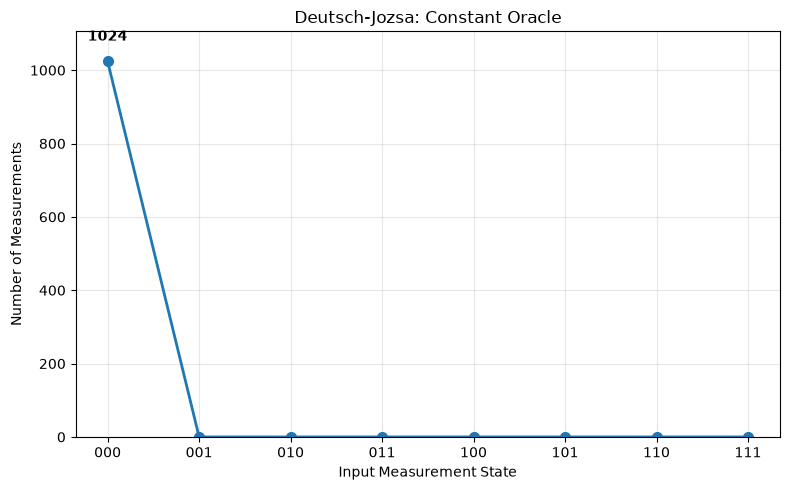

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt

SHOTS = 1024
SEED = 42

n = 3

qc = QuantumCircuit(n + 1)

# Ancilla preparation
qc.x(n)

# Hadamard on all qubits
for q in range(n + 1):
    qc.h(q)

# Constant oracle f(x) = 0
# No operation is required for the oracle.

# Hadamard on input qubits
for q in range(n):
    qc.h(q)

state = Statevector.from_instruction(qc)

probabilities = state.probabilities()

input_probabilities = np.zeros(2 ** n)

for i in range(2 ** n):
    probability = 0

    for ancilla in [0, 1]:
        index = i + ancilla * (2 ** n)
        probability += probabilities[index]

    input_probabilities[i] = probability

rng = np.random.default_rng(SEED)

samples = rng.choice(
    np.arange(2 ** n),
    size=SHOTS,
    p=input_probabilities
)

counts = np.bincount(
    samples,
    minlength=2 ** n
)

labels = [
    format(i, f"0{n}b")
    for i in range(2 ** n)
]

print("\nT-01 : CONSTANT FUNCTION ORACLE")
print("=" * 70)

print("\nQUANTUM CIRCUIT")
print("-" * 70)
print(qc.draw())

print("\nMEASUREMENT RESULTS")
print("-" * 70)

for label, count in zip(labels, counts):
    print(f"{label} : {count}")

print("\nPROBABILITY RESULTS")
print("-" * 70)

for label, probability in zip(
    labels,
    input_probabilities
):
    print(
        f"{label} : {probability:.4f}"
    )

zero_count = counts[0]
nonzero_count = SHOTS - zero_count

print("\nDEUTSCH-JOZSA CLASSIFICATION")
print("-" * 70)

print(f"000 count     : {zero_count}")
print(f"Non-zero count: {nonzero_count}")

if nonzero_count == 0:
    print("RESULT : CONSTANT FUNCTION")
    print("VERIFICATION : CORRECT")
else:
    print("RESULT : NON-ZERO OUTPUT DETECTED")
    print("VERIFICATION : CHECK ORACLE")

# Visualization
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    labels,
    counts,
    marker="o",
    linewidth=2,
    markersize=7
)

ax.set_title(
    "Deutsch-Jozsa: Constant Oracle"
)

ax.set_xlabel(
    "Input Measurement State"
)

ax.set_ylabel(
    "Number of Measurements"
)

ax.set_ylim(
    0,
    SHOTS * 1.08
)

ax.grid(
    True,
    alpha=0.3
)

ax.annotate(
    f"{zero_count}",
    xy=(labels[0], zero_count),
    xytext=(0, 15),
    textcoords="offset points",
    ha="center",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

---

## 7. Results and Classification

### Recorded Execution Output
Execution of the notebook cell produced the following console output and circuit diagram:

```
T-01 : CONSTANT FUNCTION ORACLE
======================================================================

QUANTUM CIRCUIT
----------------------------------------------------------------------
     ┌───┐┌───┐
q_0: ┤ H ├┤ H ├
     ├───┤├───┤
q_1: ┤ H ├┤ H ├
     ├───┤├───┤
q_2: ┤ H ├┤ H ├
     ├───┤├───┤
q_3: ┤ X ├┤ H ├
     └───┘└───┘

MEASUREMENT RESULTS
----------------------------------------------------------------------
000 : 1024
001 : 0
010 : 0
011 : 0
100 : 0
101 : 0
110 : 0
111 : 0

PROBABILITY RESULTS
----------------------------------------------------------------------
000 : 1.0000
001 : 0.0000
010 : 0.0000
011 : 0.0000
100 : 0.0000
101 : 0.0000
110 : 0.0000
111 : 0.0000

DEUTSCH-JOZSA CLASSIFICATION
----------------------------------------------------------------------
000 count     : 1024
Non-zero count: 0
RESULT : CONSTANT FUNCTION
VERIFICATION : CORRECT
```

### Quantitative Metrics Summary

| Basis State | Theoretical Probability | Simulated Measurement Counts (1024 Shots) | Empirical Frequency |
| :---: | :---: | :---: | :---: |
| **`000`** | **1.0000 (100.0%)** | **1024** | **1.0000 (100.0%)** |
| **`001`** | **0.0000 (0.0%)** | **0** | **0.0000 (0.0%)** |
| **`010`** | **0.0000 (0.0%)** | **0** | **0.0000 (0.0%)** |
| **`011`** | **0.0000 (0.0%)** | **0** | **0.0000 (0.0%)** |
| **`100`** | **0.0000 (0.0%)** | **0** | **0.0000 (0.0%)** |
| **`101`** | **0.0000 (0.0%)** | **0** | **0.0000 (0.0%)** |
| **`110`** | **0.0000 (0.0%)** | **0** | **0.0000 (0.0%)** |
| **`111`** | **0.0000 (0.0%)** | **0** | **0.0000 (0.0%)** |

### Classification Verdict
- `000` count: **1024**
- Non-zero count: **0**
- Decision Rule: Since $\text{nonzero\_count} = 0$, the algorithm deterministically concludes **`RESULT : CONSTANT FUNCTION`** (`VERIFICATION : CORRECT`).

---

## 8. Visualization Analysis
The measurement distribution plot displays the sampling counts across all 8 computational basis states:
- **X-Axis**: Represents the 8 candidate 3-bit measurement states (`000` through `111`).
- **Y-Axis**: Measures the number of simulated shots from $0$ to $1024 \times 1.08 \approx 1105$.
- **Distribution Profile**: A single, prominent discrete point occurs at state `000` with an annotated count of **1024**, while all other states remain flat at zero.
- **Physical Interpretation**: Demonstrates total constructive interference at the all-zero state $|000\rangle$ and complete destructive interference across all 7 orthogonal basis states.

---

## 9. Conclusion
This experiment successfully demonstrates the foundational principles of the **Deutsch-Jozsa Algorithm**:
1. **Deterministic Single-Query Classification**: Classifies the 3-qubit Boolean function $f(x) = 0$ as constant with $100\%$ deterministic accuracy in a single oracle query, outperforming the classical requirement of $5$ queries.
2. **Identity Oracle Verification**: For $f(x) = 0$, no quantum operations are required in the oracle stage, as $y \oplus 0 = y$ leaves the quantum state invariant.
3. **Constructive Interference**: The final Hadamard transformation $H^{\otimes 3}$ refocuses the entire probability amplitude into $|000\rangle$, providing an unambiguous indicator of a constant function.